In [2]:
import pandas as pd

In [10]:
## import the dfs
income_race_df = pd.read_csv("nyc_income_race_data.csv")

In [44]:
income_race_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2327 entries, 0 to 2326
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   NAME         2327 non-null   object
 1   B19013_001E  2327 non-null   int64 
 2   B02001_002E  2327 non-null   int64 
 3   B02001_003E  2327 non-null   int64 
 4   B02001_004E  2327 non-null   int64 
 5   B02001_005E  2327 non-null   int64 
 6   B02001_006E  2327 non-null   int64 
 7   B02001_007E  2327 non-null   int64 
 8   B02001_008E  2327 non-null   int64 
 9   state        2327 non-null   int64 
 10  county       2327 non-null   object
 11  tract        2327 non-null   int64 
dtypes: int64(10), object(2)
memory usage: 218.3+ KB


In [46]:
income_race_df["tract"].unique()

array([  100,   200,   400, ..., 30302, 31901, 31902])

In [6]:
grocery_inspec = pd.read_csv("Andy_grocery_allinspections.csv")

In [119]:
supe_inspec = pd.read_csv("Andy_supermarkets_allinspections.csv")

In [14]:
grocery_inspec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4792 entries, 0 to 4791
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Certificate of Inspection      4792 non-null   object 
 1   Inspection Number              4792 non-null   object 
 2   Date of Occurance              4792 non-null   object 
 3   Year (added)                   4792 non-null   int64  
 4   Business Unique ID             4788 non-null   object 
 5   UniqueBusinessID_NoYear        4788 non-null   object 
 6   Business Name                  4792 non-null   object 
 7   DBA Trade Name                 759 non-null    object 
 8   Business Category              4792 non-null   object 
 9   Inspection type                4792 non-null   object 
 10  Device Category                4792 non-null   object 
 11  Device Class                   4770 non-null   object 
 12  Device Type                    4792 non-null   o

In [12]:
## Identify the geographic hotspots of GROC STORES device violations by borough, address, and postal code
filtered_groc_inspections = grocery_inspec[grocery_inspec["Devices Condemned/Confiscated"] > 0]
## Now let's filter the top boroughs 
# Drop duplicate inspections (keep one row per inspection)
unique_groc_inspections = filtered_groc_inspections.drop_duplicates(subset=["Inspection Number"])

# Now count boroughs by unique inspections
groc_borough_violations = unique_groc_inspections["Borough"].value_counts()

groc_borough_violations

Borough
Bronx            12
Brooklyn         10
Queens            9
Manhattan         7
Staten Island     2
Outside NYC       1
Name: count, dtype: int64

In [18]:
##confirm that my filtered groc inspection dataset with only businesses with devices confiscated match with my google sheet analysis. it does
filtered_groc_inspections.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 45 to 4693
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Certificate of Inspection      41 non-null     object 
 1   Inspection Number              41 non-null     object 
 2   Date of Occurance              41 non-null     object 
 3   Year (added)                   41 non-null     int64  
 4   Business Unique ID             41 non-null     object 
 5   UniqueBusinessID_NoYear        41 non-null     object 
 6   Business Name                  41 non-null     object 
 7   DBA Trade Name                 9 non-null      object 
 8   Business Category              41 non-null     object 
 9   Inspection type                41 non-null     object 
 10  Device Category                41 non-null     object 
 11  Device Class                   37 non-null     object 
 12  Device Type                    41 non-null     object 

In [28]:
cols = supe_inspec[["Devices Inspected", "Devices Approved", "Devices Condemned/Confiscated"]]


In [36]:
for col in cols:
    supe_inspec[col] = pd.to_numeric(supe_inspec[col], errors="coerce").astype("Int64")

In [38]:
## Identify the geographic hotspots of SUPERMARKETS device violations by borough, address, and postal code
filtered_supe_inspections = supe_inspec[supe_inspec["Devices Condemned/Confiscated"] > 0]

## Now let's filter the top boroughs 
# Drop duplicate inspections (keep one row per inspection)
unique_supe_inspections = filtered_supe_inspections.drop_duplicates(subset=["Inspection Number"])

# Now count boroughs by unique inspections
supe_borough_violations = unique_supe_inspections["Borough"].value_counts()

supe_borough_violations


Borough
Manhattan        18
Queens           13
Bronx            12
Brooklyn         12
Staten Island     8
Name: count, dtype: int64

In [40]:
## Now let's filter the top zip codes for GROC
# Drop duplicate inspections based on Inspection Number
unique_groc_inspections = filtered_groc_inspections.drop_duplicates(subset=["Inspection Number"])

# Count zip codes by unique inspections
zip_groc_violations = unique_groc_inspections["Postcode"].value_counts()

zip_groc_violations.head(10)

Postcode
10453    3
11214    2
10466    2
10456    2
11421    2
11209    2
10457    2
10032    2
11433    2
11355    1
Name: count, dtype: int64

In [42]:
## Now let's filter the top zip codes for SUPE
# Drop duplicate inspections based on Inspection Number
unique_supe_inspections = filtered_supe_inspections.drop_duplicates(subset=["Inspection Number"])

# Count zip codes by unique inspections
zip_supe_violations = unique_supe_inspections["Postcode"].value_counts()

zip_supe_violations.head(10)

Postcode
10010    6
10014    3
10314    3
10453    2
11433    2
10460    2
11368    2
10468    2
11435    2
10040    2
Name: count, dtype: int64

In [60]:
##add census tract to grocery store all inspections

import geopandas as gpd
from shapely.geometry import Point

# Convert to GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    grocery_inspec, 
    geometry=gpd.points_from_xy(grocery_inspec.Longitude, grocery_inspec.Latitude), 
    crs="EPSG:4326"
)

# Load Census tract shapefile (NY = state FIPS 36)
tracts = gpd.read_file("tl_2024_36_tract/tl_2024_36_tract.shp")

# Ensure both layers use same CRS
tracts = tracts.to_crs("EPSG:4326")

# Spatial join: adds tract info to each row
gdf_with_tracts = gpd.sjoin(gdf_points, tracts, how="left", predicate="within")

# Save or view results
gdf_with_tracts.to_csv("dataset_with_tracts.csv", index=False)

In [121]:
## convert supermarkets to float

supe_inspec["Longitude"] = pd.to_numeric(supe_inspec["Longitude"], errors="coerce")
supe_inspec["Latitude"] = pd.to_numeric(supe_inspec["Latitude"], errors="coerce")

In [125]:
# Now SUPERMARKETS
gdf_points_supe = gpd.GeoDataFrame(
    supe_inspec, 
    geometry=gpd.points_from_xy(supe_inspec.Longitude, supe_inspec.Latitude), 
    crs="EPSG:4326"
)

# Spatial join: adds tract info to each row
gdf_with_tracts_supe = gpd.sjoin(gdf_points_supe, tracts, how="left", predicate="within")

# Save or view results
gdf_with_tracts_supe.to_csv("supe_2_tracts.csv", index=False)

In [68]:
##merge grocery with tract data set and nyc income race dataset
groc_tracts = pd.read_csv("All_groc_inspections_tract.csv")

groc_tracts['TRACTCE'] = groc_tracts['TRACTCE'].astype(str).str.zfill(6)
income_race_df['tract'] = income_race_df['tract'].astype(str).str.zfill(6)


In [80]:
income_race_df.head(10)

,NAME,B19013_001E,B02001_002E,B02001_003E,B02001_004E,B02001_005E,B02001_006E,B02001_007E,B02001_008E,state,county,tract
0,Census Tract 1; Bronx County; New York,-666666666,1393,1610,10,79,0,240,206,36,Bronx,000100
1,Census Tract 2; Bronx County; New York,121171,782,1671,0,311,0,1874,539,36,Bronx,000200
2,Census Tract 4; Bronx County; New York,98242,532,2767,0,19,0,2351,812,36,Bronx,000400
3,Census Tract 16; Bronx County; New York,42957,260,2357,151,282,0,2360,601,36,Bronx,001600
4,Census Tract 19.01; Bronx County; New York,67361,513,1154,36,12,0,566,120,36,Bronx,001901
5,Census Tract 19.02; Bronx County; New York,76429,115,423,26,23,500,565,327,36,Bronx,001902
6,Census Tract 19.03; Bronx County; New York,-666666666,0,0,0,0,0,0,0,36,Bronx,001903
7,Census Tract 19.04; Bronx County; New York,-666666666,0,0,0,0,0,0,0,36,Bronx,001904
8,Census Tract 20.01; Bronx County; New York,23208,626,1775,53,0,0,1316,530,36,Bronx,002001
9,Census Tract 20.02; Bronx County; New York,18029,596,1069,0,0,0,1511,513,36,Bronx,002002


In [70]:
##match tract names
groc_tracts = groc_tracts.rename(columns={'TRACTCE': 'tract'})

In [82]:
groc_tracts['tract'] = groc_tracts['tract'].astype(str).str.zfill(6)
income_race_df['tract'] = income_race_df['tract'].astype(str).str.zfill(6)

In [88]:
groc_tracts['tract'] = groc_tracts['tract'].str.strip()
income_race_df['tract'] = income_race_df['tract'].str.strip()

In [90]:
missing_in_income_race_df = groc_tracts.loc[~groc_tracts['tract'].isin(income_race_df['tract']), 'tract']
print(missing_in_income_race_df)

0        6902.0
1        6902.0
2       20100.0
3       15300.0
4       15300.0
         ...   
4787    71306.0
4788     0900.0
4789     0900.0
4790    19600.0
4791    26900.0
Name: tract, Length: 4792, dtype: object


In [97]:
# Convert to int first (to remove the .0), then to string with 6 digits
# Remove the decimal part and convert to int, then to string with 6 digits
income_race_df['tract'] = income_race_df['tract'].astype(float).astype(int).astype(str).str.zfill(6)
groc_tracts['tract'] = groc_tracts['tract'].astype(float).astype(int).astype(str).str.zfill(6)

ValueError: could not convert string to float: '000nan'

In [101]:
import numpy as np
def clean_tract_column(col):
    def fix_tract(x):
        try:
            # Try converting to float first (handles '6902.0'), then int
            num = int(float(x))
            # Convert to 6-digit string
            return str(num).zfill(6)
        except:
            # If conversion fails, mark as invalid
            return np.nan
    
    # Apply function to the column
    cleaned_col = col.apply(fix_tract)
    return cleaned_col

# Apply to both datasets
income_race_df['tract_clean'] = clean_tract_column(income_race_df['tract'])
groc_tracts['tract_clean'] = clean_tract_column(groc_tracts['tract'])

# Optional: check how many invalid tracts
print("Invalid tracts in df1:", income_race_df['tract_clean'].isna().sum())
print("Invalid tracts in df2:", groc_tracts['tract_clean'].isna().sum())

# Merge on the cleaned tract column
merged = pd.merge(income_race_df, groc_tracts, left_on='tract_clean', right_on='tract_clean', how='left')

Invalid tracts in df1: 0
Invalid tracts in df2: 6


In [103]:
merged.head(10)

,NAME_x,B19013_001E,B02001_002E,B02001_003E,B02001_004E,B02001_005E,B02001_006E,B02001_007E,B02001_008E,state,...,GEOID,GEOIDFQ,NAME_y,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON
0,Census Tract 1; Bronx County; New York,-666666666,1393,1610,10,79,0,240,206,36,...,3.604700e+10,1400000US36047000100,1.0,Census Tract 1,G5020,S,207819.0,0.0,40.700215,-73.993809
1,Census Tract 1; Bronx County; New York,-666666666,1393,1610,10,79,0,240,206,36,...,3.604700e+10,1400000US36047000100,1.0,Census Tract 1,G5020,S,207819.0,0.0,40.700215,-73.993809
2,Census Tract 2; Bronx County; New York,121171,782,1671,0,311,0,1874,539,36,...,3.600500e+10,1400000US36005000200,2.0,Census Tract 2,G5020,S,448105.0,852406.0,40.808245,-73.856723
3,Census Tract 2; Bronx County; New York,121171,782,1671,0,311,0,1874,539,36,...,3.608100e+10,1400000US36081000200,2.0,Census Tract 2,G5020,S,156595.0,0.0,40.693292,-73.866158
4,Census Tract 2; Bronx County; New York,121171,782,1671,0,311,0,1874,539,36,...,3.604700e+10,1400000US36047000200,2.0,Census Tract 2,G5020,S,276929.0,0.0,40.653247,-74.011068
5,Census Tract 2; Bronx County; New York,121171,782,1671,0,311,0,1874,539,36,...,3.604700e+10,1400000US36047000200,2.0,Census Tract 2,G5020,S,276929.0,0.0,40.653247,-74.011068
6,Census Tract 2; Bronx County; New York,121171,782,1671,0,311,0,1874,539,36,...,3.604700e+10,1400000US36047000200,2.0,Census Tract 2,G5020,S,276929.0,0.0,40.653247,-74.011068
7,Census Tract 2; Bronx County; New York,121171,782,1671,0,311,0,1874,539,36,...,3.604700e+10,1400000US36047000200,2.0,Census Tract 2,G5020,S,276929.0,0.0,40.653247,-74.011068
8,Census Tract 2; Bronx County; New York,121171,782,1671,0,311,0,1874,539,36,...,3.608100e+10,1400000US36081000200,2.0,Census Tract 2,G5020,S,156595.0,0.0,40.693292,-73.866158
9,Census Tract 4; Bronx County; New York,98242,532,2767,0,19,0,2351,812,36,...,3.608100e+10,1400000US36081000400,4.0,Census Tract 4,G5020,S,224878.0,0.0,40.689683,-73.864772


In [105]:
merged.to_csv("Merged_grocery_store_income.csv")

In [131]:
##merge SUPE with tract data set and nyc income race dataset

gdf_with_tracts_supe = gdf_with_tracts_supe.rename(columns={'TRACTCE': 'tract'})

gdf_with_tracts_supe['tract'] = gdf_with_tracts_supe['tract'].astype(str).str.zfill(6)
income_race_df['tract'] = income_race_df['tract'].astype(str).str.zfill(6)


In [133]:
import numpy as np
def clean_tract_column(col):
    def fix_tract(x):
        try:
            # Try converting to float first (handles '6902.0'), then int
            num = int(float(x))
            # Convert to 6-digit string
            return str(num).zfill(6)
        except:
            # If conversion fails, mark as invalid
            return np.nan
    
    # Apply function to the column
    cleaned_col = col.apply(fix_tract)
    return cleaned_col

# Apply to both datasets
income_race_df['tract_clean'] = clean_tract_column(income_race_df['tract'])
gdf_with_tracts_supe['tract_clean'] = clean_tract_column(gdf_with_tracts_supe['tract'])

# Optional: check how many invalid tracts
print("Invalid tracts in df1:", income_race_df['tract_clean'].isna().sum())
print("Invalid tracts in df2:", gdf_with_tracts_supe['tract_clean'].isna().sum())

# Merge on the cleaned tract column
merged_supe = pd.merge(income_race_df, gdf_with_tracts_supe, left_on='tract_clean', right_on='tract_clean', how='left')

Invalid tracts in df1: 0
Invalid tracts in df2: 3


In [135]:
merged_supe.head(10)

,NAME_x,B19013_001E,B02001_002E,B02001_003E,B02001_004E,B02001_005E,B02001_006E,B02001_007E,B02001_008E,state,...,GEOID,GEOIDFQ,NAME_y,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON
0,Census Tract 1; Bronx County; New York,-666666666,1393,1610,10,79,0,240,206,36,...,36047000100,1400000US36047000100,1,Census Tract 1,G5020,S,207819.0,0.0,+40.7002150,-073.9938089
1,Census Tract 2; Bronx County; New York,121171,782,1671,0,311,0,1874,539,36,...,36081000200,1400000US36081000200,2,Census Tract 2,G5020,S,156595.0,0.0,+40.6932923,-073.8661578
2,Census Tract 2; Bronx County; New York,121171,782,1671,0,311,0,1874,539,36,...,36081000200,1400000US36081000200,2,Census Tract 2,G5020,S,156595.0,0.0,+40.6932923,-073.8661578
3,Census Tract 2; Bronx County; New York,121171,782,1671,0,311,0,1874,539,36,...,36081000200,1400000US36081000200,2,Census Tract 2,G5020,S,156595.0,0.0,+40.6932923,-073.8661578
4,Census Tract 2; Bronx County; New York,121171,782,1671,0,311,0,1874,539,36,...,36047000200,1400000US36047000200,2,Census Tract 2,G5020,S,276929.0,0.0,+40.6532475,-074.0110678
5,Census Tract 2; Bronx County; New York,121171,782,1671,0,311,0,1874,539,36,...,36047000200,1400000US36047000200,2,Census Tract 2,G5020,S,276929.0,0.0,+40.6532475,-074.0110678
6,Census Tract 2; Bronx County; New York,121171,782,1671,0,311,0,1874,539,36,...,36047000200,1400000US36047000200,2,Census Tract 2,G5020,S,276929.0,0.0,+40.6532475,-074.0110678
7,Census Tract 4; Bronx County; New York,98242,532,2767,0,19,0,2351,812,36,...,36081000400,1400000US36081000400,4,Census Tract 4,G5020,S,224878.0,0.0,+40.6896831,-073.8647717
8,Census Tract 4; Bronx County; New York,98242,532,2767,0,19,0,2351,812,36,...,36081000400,1400000US36081000400,4,Census Tract 4,G5020,S,224878.0,0.0,+40.6896831,-073.8647717
9,Census Tract 16; Bronx County; New York,42957,260,2357,151,282,0,2360,601,36,...,36005001600,1400000US36005001600,16,Census Tract 16,G5020,S,485078.0,0.0,+40.8188478,-073.8580764


In [137]:
merged_supe.to_csv("Merged_SUPE_income.csv")

In [139]:
plot_groc_merge = pd.read_csv("Sum_CLEAN_GROC_ForPlot.csv")
plot_supe_merge = pd.read_csv("Sum_CLEAN_SUPE_ForPlot.csv")

In [141]:
plot_groc_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11066 entries, 0 to 11065
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   NAME_x                    11066 non-null  object
 1   Med_House_Income          11066 non-null  object
 2   White_Alone_Pop           11066 non-null  object
 3   Black_Alone_Pop           11066 non-null  object
 4   AmIndian_Alone_Pop        11066 non-null  int64 
 5   Asian_Alone_Pop           11066 non-null  object
 6   HawPacIslander_Alone_Pop  11066 non-null  int64 
 7   Other_race_Alone          11066 non-null  object
 8   Two_or_More_races         11066 non-null  object
 9   Total_Pop                 11066 non-null  object
 10  Minority_pct              11066 non-null  object
 11  State_FIPS                11066 non-null  int64 
 12  county                    11066 non-null  object
 13  tract_clean               11066 non-null  int64 
 14  COUNT_inspections_trac

In [169]:
groc_pct_sep11 = pd.read_csv("sep11_plot_pctg_groc.csv")

## LETS MAKE THE PLOT LIB of grocery stores and , plotting med house income against confiscations total in tract

In [172]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure numeric columns are floats
numeric_cols = ["Minority_pct", "CONF_pct", "INSPECT_pct", "Med_House_Income"]
for col in numeric_cols:
    plot_groc_merge[col] = pd.to_numeric(plot_groc_merge[col], errors='coerce')

# Scatter plot: Sum confiscations % vs Median Income
plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_groc_merge, x="Med_House_Income", y="CONF_pct")
sns.regplot(data=plot_groc_merge, x="Med_House_Income", y="CONF_pct",
            scatter=False, color='red', line_kws={"linewidth":2})
plt.title("Grocery Scale Confiscations vs Median Household Income")
plt.xlabel("Median Household Income ($)")
plt.ylabel("Total Confiscations")
plt.grid(True)
plt.savefig("groc_conf_vs_income.png")  # saves image
plt.show()

# Scatter plot: Sum confiscations vs Minority %
plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_groc_merge, x="Minority_pct", y="SUM_confiscations")
sns.regplot(data=plot_groc_merge, x="Minority_pct", y="SUM_confiscations",
            scatter=False, color='red', line_kws={"linewidth":2})
plt.title("Grocery Scale Confiscations vs Minority Population %")
plt.xlabel("Minority Population %")
plt.ylabel("Total Confiscations")
plt.grid(True)
plt.savefig("groc_conf_vs_minority.png")
plt.show()

KeyError: 'CONF_pct'

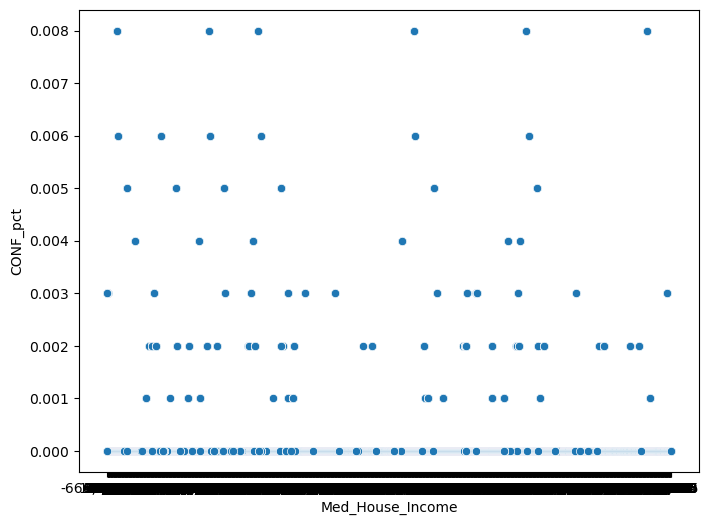

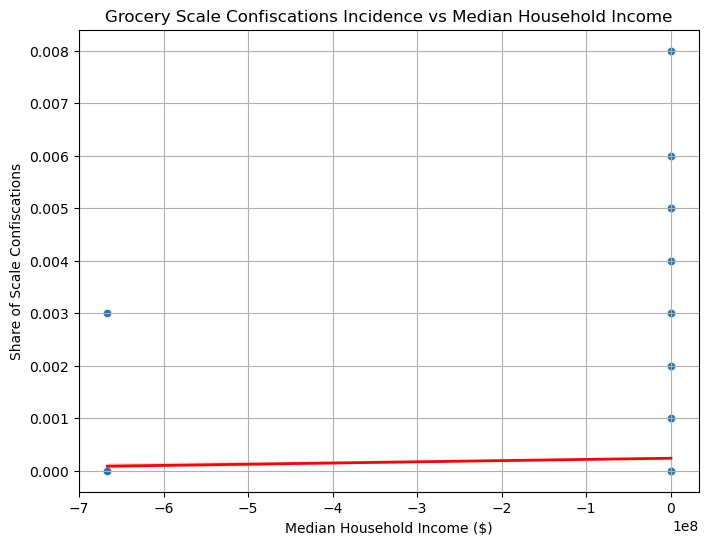

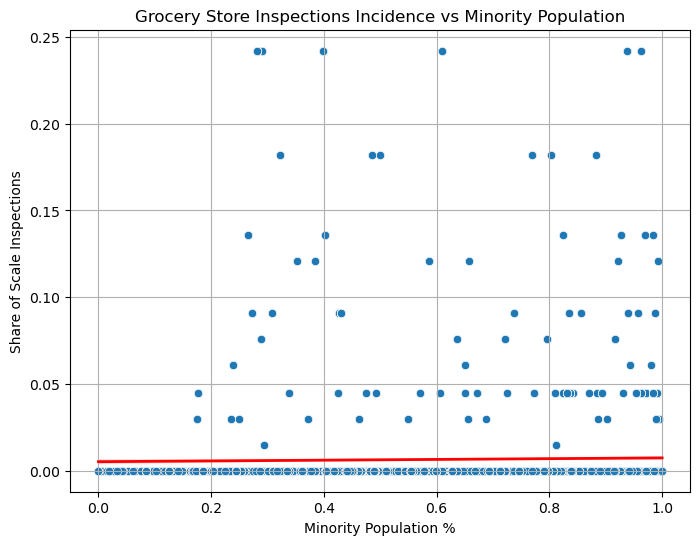

In [159]:
## rework the conf and inspec percentages to render a more pertinent graph of correlation

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure numeric columns are floats
numeric_cols = ["Minority_pct", "CONF_pct", "INSPECT_pct", "Med_House_Income"]  # Added Med_House_Income
for col in numeric_cols:
    # Convert to string first to handle any potential mixed types, then to float
    groc_pct_sep11[col] = groc_pct_sep11[col].astype(str).str.replace(',', '').str.replace('$', '')
    groc_pct_sep11[col] = pd.to_numeric(groc_pct_sep11[col], errors='coerce')

# Scatter plot: PCT confiscations in tract vs Median Income in tract
plt.figure(figsize=(8,6))
sns.scatterplot(data=groc_pct_sep11, x="Med_House_Income", y="CONF_pct")
sns.regplot(data=groc_pct_sep11, x="Med_House_Income", y="CONF_pct",
            scatter=False, color='red', line_kws={"linewidth":2})
plt.title("Grocery Scale Confiscations Incidence vs Median Household Income")
plt.xlabel("Median Household Income ($)")
plt.ylabel("Share of Scale Confiscations")
plt.grid(True)
plt.savefig("groc_conf_PCT_vs_income.png")  # saves image
plt.show()

# Scatter plot: PCT inspections in tract vs Minority % in tract
plt.figure(figsize=(8,6))
sns.scatterplot(data=groc_pct_sep11, x="Minority_pct", y="INSPECT_pct")
sns.regplot(data=groc_pct_sep11, x="Minority_pct", y="INSPECT_pct",
            scatter=False, color='red', line_kws={"linewidth":2})
plt.title("Grocery Store Inspections Incidence vs Minority Population")
plt.xlabel("Minority Population %")
plt.ylabel("Share of Scale Inspections")
plt.grid(True)
plt.savefig("groc_inspec_pct_vs_minority.png")
plt.show()